# Лекция 2: **Сбор и предобработка данных для анализа судебной практики**
### **Цель лекции:** Понять процесс сбора и предобработки данных для анализа судебных актов, изучить методы извлечения данных из различных источников, познакомиться с инструментами и техниками, используемыми для очистки и подготовки данных к дальнейшему анализу.
---
## **Введение**
Здравствуйте, уважаемые студенты!
Сегодня мы продолжим наш цикл лекций и поговорим о первом и очень важном шаге в построении любой аналитической системы — сборе и предобработке данных. Качество данных напрямую влияет на качество моделей машинного обучения. Неподготовленные данные могут привести к некорректным результатам и выводам. Правильная предобработка данных может значительно улучшить производительность моделей.


---
## **1. Основные понятия и определения**
**Данные** — это совокупность фактов, цифр, текстов или других элементов, которые могут быть обработаны для получения информации. В контексте нашей задачи данные — это тексты судебных актов и связанных с ними документов.
**Сбор данных** — процесс получения данных из различных источников для дальнейшего анализа. Это может включать как структурированные, так и неструктурированные данные, а также обеспечивать их высокое качество.
**Предобработка данных** — совокупность методов и техник, направленных на приведение данных в формат, подходящий для анализа и обучения моделей. Эффективная предобработка существенно повышает точность и надежность аналитических выводов.

---
## **2. Источники данных**
### **2.1. Официальные сайты и базы данных**
Основным источником судебных актов являются официальные сайты судов и государственные базы данных. Например, электронная картотека арбитражных дел (https://kad.arbitr.ru/).
### **2.2. Особенности данных**
Различные форматы документов, такие как .docx, .pdf и .html, требуют специфического подхода к обработке. Данные могут быть как структурированными, так и неструктурированными, поэтому важно учитывать наличие "шума", который включает ненужную информацию, ошибки и дубликаты.

---
## **3. Сбор данных**
### **3.1. Автоматизация сбора данных**
Для эффективной работы с большим объемом данных необходимо автоматизировать процесс сбора. Это решение позволяет избежать недостатков ручного ввода, таких как временные затраты и человеческие ошибки.
### **3.2. Парсинг веб-сайтов**
**Парсинг** — процесс извлечения нужной информации из веб-страницы. Примеры задач парсинга включают сбор ссылок на документы и извлечение текста из веб-страниц.
### **3.3. Пример кода для парсинга**
**Пример кода для сбора данных.**
```python
import requests
from bs4 import BeautifulSoup
def get_case_links(page_url):
    response = requests.get(page_url)
    soup = BeautifulSoup(response.content, 'html.parser')
    links = []
    for a_tag in soup.find_all('a', href=True):
        if 'CaseId' in a_tag['href']:
            links.append(a_tag['href'])
    return links
# Пример использования
page_url = 'https://kad.arbitr.ru/'
case_links = get_case_links(page_url)
print(case_links)
```
**Объяснение кода:**
- **requests.get:** Получает содержимое веб-страницы.
- **BeautifulSoup:** Библиотека для разбора HTML-кода.
- **soup.find_all('a', href=True):** Находит все ссылки на странице.
- **Фильтрация ссылок:** Оставляем только те, которые содержат 'CaseId'.
### **3.4. Работа с API**
Некоторые ресурсы предоставляют API для доступа к данным. API (Application Programming Interface) — интерфейс программирования приложений, позволяющий взаимодействовать с программным обеспечением через набор определенных запросов и функций. Использование API обеспечивает надежный доступ к структурированным данным и упрощает процесс интеграции.


---
## **4. Предобработка данных**
После сбора данных необходимо привести их в вид, пригодный для дальнейшего анализа.
### **4.1. Очистка данных**
**Цель очистки данных:**
- Удаление ненужной информации.
- Исправление ошибок.
- Устранение дубликатов.
**Этапы очистки:**
1. **Удаление HTML-тегов и спецсимволов**
   ```python
   import re
   def clean_html(raw_html):
       clean_text = re.sub('<.*?>', '', raw_html)
       return clean_text
   # Пример использования
   html_text = "<p>Пример текста</p>"
   text = clean_html(html_text)
   print(text)  # Вывод: "Пример текста"
   ```
2. **Удаление цифр и пунктуации**
   ```python
   import string
   def remove_punctuation_and_numbers(text):
       translator = str.maketrans('', '', string.punctuation + string.digits)
       return text.translate(translator)
   # Пример использования
   raw_text = "Текст с цифрами 123 и знаками препинания!!!"
   cleaned_text = remove_punctuation_and_numbers(raw_text)
   print(cleaned_text)  # Вывод: "Текст с цифрами  и знаками препинания"
   ```
3. **Приведение к нижнему регистру**
   ```python
   def lowercase(text):
       return text.lower()
   # Пример использования
   text = "ПрИмеР ТекстА"
   print(lowercase(text))  # Вывод: "пример текста"
   ```

### **4.2. Токенизация**
**Определение:**
**Токенизация** — процесс разбиения текста на отдельные элементы — токены (слова, пункты, предложения). Это позволяет упростить дальнейшую обработку текста.
```python
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize, sent_tokenize
text = "Это пример. Токенизация текста важна для NLP."
words = word_tokenize(text)
sentences = sent_tokenize(text)
print("Слова:", words)
print("Предложения:", sentences)
```
**Вывод:**
```
Слова: ['Это', 'пример', '.', 'Токенизация', 'текста', 'важна', 'для', 'NLP', '.']
Предложения: ['Это пример.', 'Токенизация текста важна для NLP.']
```

### **4.3. Удаление стоп-слов**
**Стоп-слова** — это слова, которые часто встречаются в языке, но не несут значимой информации (например, "и", "в", "на"). Удаление стоп-слов позволяет сфокусироваться на более значимых словах в анализируемом тексте.
```python
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))
def remove_stopwords(words):
    return [word for word in words if word not in stop_words]
# Пример использования
words = ['Это', 'пример', 'текста', 'без', 'стоп-слов']
filtered_words = remove_stopwords(words)
print(filtered_words)
```
**Вывод:**
```
['пример', 'текста', 'без', 'стоп-слов']
```

### **4.4. Стемминг и лемматизация**
**Стемминг** — это процедура приведения слов к их основе (стему), в то время как **лемматизация** приводит слова к их начальной форме (лемме), учитывая грамматические свойства слова.
**Пример лемматизации с использованием pymorphy2:**
```python
import pymorphy2
morph = pymorphy2.MorphAnalyzer()
def lemmatize(words):
    lemmas = []
    for word in words:
        lemma = morph.parse(word)[0].normal_form
        lemmas.append(lemma)
    return lemmas
# Пример использования
words = ['тексты', 'обрабатываются', 'для', 'классификации']
lemmas = lemmatize(words)
print(lemmas)
```
**Вывод:**
```
['текст', 'обрабатываться', 'для', 'классификация']
```

---
## **5. Извлечение ключевых сущностей**
Извлечение определенных сущностей, таких как заявления, ответчики и аргументы, играет ключевую роль в анализе судебных документов.
### **5.1. Распознавание именованных сущностей (NER)**
**NER (Named Entity Recognition)** — это задача выделения именованных сущностей и определения их типов из текста.
**Пример с использованием библиотеки Natasha:**
```python
from natasha import Doc, NewsNERTagger, NewsEmbedding, Segmenter
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)
def extract_named_entities(text):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)
    entities = [(ent.text, ent.type) for ent in doc.spans]
    return entities
# Пример использования
text = "Исковое заявление ООО 'Пример' к ПАО 'Судебный' о взыскании долга."
entities = extract_named_entities(text)
print(entities)
```
**Вывод:**
```
[("ООО 'Пример'", 'ORG'), ("ПАО 'Судебный'", 'ORG')]
```

### **5.2. Регулярные выражения**
Регулярные выражения представляют собой мощный инструмент для извлечения специфической информации из текста.
**Пример: извлечение номеров статей закона**
```python
import re
def extract_law_articles(text):
    pattern = r'st\.?\s*\d+\s*(?:[а-яА-Я]*)'
    matches = re.findall(pattern, text)
    return matches
# Пример использования
text = "Согласно ст. 127-ФЗ, необходимо соблюдать требования ст. 9 закона."
articles = extract_law_articles(text)
print(articles)
```
**Вывод:**
```
['ст. 127', 'ст. 9']
```

---
## **6. Классификация судебных актов по ключевым словам**
После предобработки данных и извлечения сущностей необходимо классифицировать документы по категориям.
### **6.1. Определение категорий**
Из конспекта мы имеем список классов документов, например:
- **Оспаривание сделок должника**
- **Привлечение к субсидиарной ответственности**
- **Обжалование решений налогового органа**
- **И многое другое**
### **6.2. Подходы к классификации**
1. **Анализ ключевых фраз**
   - Экспертно подобранные ключевые слова для каждого класса.
   - Сравнение слов в документе с ключевыми словами.
2. **Анализ названий категорий**
   - Использование названий классов как ключевых слов.
3. **Анализ статей закона**
   - Поиск упоминаний определенных статей закона в тексте.
### **6.3. Пример реализации анализа ключевых фраз**
#### Шаги:
1. Создаем словарь ключевых слов для каждого класса.
   ```python
   class_keywords = {
       'Оспаривание сделок должника': ['оспаривание сделки', 'сделки должника'],
       'Привлечение к субсидиарной ответственности': ['субсидиарная ответственность', 'привлечение'],
       # Добавляем остальные классы
   }
   ```
2. Функция классификации документа
   ```python
   def classify_document(text, class_keywords):
       for class_name, keywords in class_keywords.items():
           for keyword in keywords:
               if keyword in text:
                   return class_name
       return 'Не определено'
   ```
3. Пример использования
   ```python
   text = "В данном деле рассматривается вопрос о привлечении к субсидиарной ответственности."
   document_class = classify_document(text, class_keywords)
   print(f'Класс документа: {document_class}')
   ```
   **Вывод:**
   ```
   Класс документа: Привлечение к субсидиарной ответственности
   ```

### **6.4. Анализ статей закона**
#### Шаги:
1. **Создаем словарь классов со списком статей**
   ```python
   class_articles = {
       'Оспаривание сделок должника': ['ст.61.2', 'ст.61.3'],
       'Привлечение к субсидиарной ответственности': ['ст.61.11', 'ст.61.12'],
       # Добавляем остальные классы
   }
   ```
2. Функция поиска статей в тексте
   ```python
   def find_law_articles(text):
       pattern = r'st\.?\s*\d+\.?\d*'
       matches = re.findall(pattern, text)
       return matches
   ```
3. Функция классификации по статьям
   ```python
   def classify_by_articles(text, class_articles):
       articles_in_text = find_law_articles(text)
       for class_name, articles in class_articles.items():
           for article in articles:
               if article in articles_in_text:
                   return class_name
       return 'Не определено'
   ```
4. Пример использования
   ```python
   text = "Согласно ст.61.2 закона о банкротстве, сделка может быть оспорена."
   document_class = classify_by_articles(text, class_articles)
   print(f'Класс документа: {document_class}')
   ```
   **Вывод:**
   ```
   Класс документа: Оспаривание сделок должника
   ```

## **7. Оценка качества классификации**
### **7.1. Метрики качества**
- **Accuracy (Точность):** Доля правильно классифицированных документов.
- **Precision (Прецизионность):** Доля правильно классифицированных документов среди всех, отнесенных к данному классу.
- **Recall (Полнота):** Доля правильно классифицированных документов среди всех документов этого класса в выборке.
- **F1-score:** Гармоническое среднее Precision и Recall.
### **7.2. Пример расчета метрик**
Предположим, у нас есть результаты классификации:
- **Количество документов в выборке:** 100
- **Правильно классифицировано:** 80
- **Отнесено к классу "Оспаривание сделок должника":** 50
- **Из них правильно отнесено:** 40
- **Общее количество документов класса "Оспаривание сделок должника" в выборке:** 45
**Вычислим метрики для класса "Оспаривание сделок должника":**
- **Precision:**
  \[
  Precision = \frac{TP}{TP + FP} = \frac{40}{50} = 0.8
  \]
- **Recall:**
  \[
  Recall = \frac{TP}{TP + FN} = \frac{40}{45} \approx 0.8889
  \]
- **F1-score:**
  \[
  F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} \approx 0.8421
  \]
### **7.3. Выводы из метрик**
- Высокие значения Precision и Recall указывают на хорошее качество классификации.
- Баланс между Precision и Recall важен для общего восприятия модели.

---
## **8. Визуализация результатов**
### **8.1. Построение матрицы ошибок (Confusion Matrix)**
**Матрицаошибок** отображает количество правильных и ошибочных классификаций по каждому классу. Это позволяет наглядно оценить качество классификации.
**Пример использования библиотеки scikit-learn:**
```python
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# y_true - истинные метки классов
# y_pred - предсказанные моделью метки классов
cm = confusion_matrix(y_true, y_pred, labels=class_names)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.show()
```
**Объяснение:**
- **confusion_matrix:** Функция для вычисления матрицы ошибок с использованием истинных и предсказанных меток классов.
- **sns.heatmap:** Используется для визуализации матрицы ошибок с аннотациями, что позволяет быстро оценить качество классификации.
### **8.2. Ссылка на рисунки из конспекта**
**Рисунки 1, 2** демонстрируют результаты оценки качества методов классификации. Они показывают количество документов, классифицированных каждым методом, а также результаты выборочной проверки экспертами.
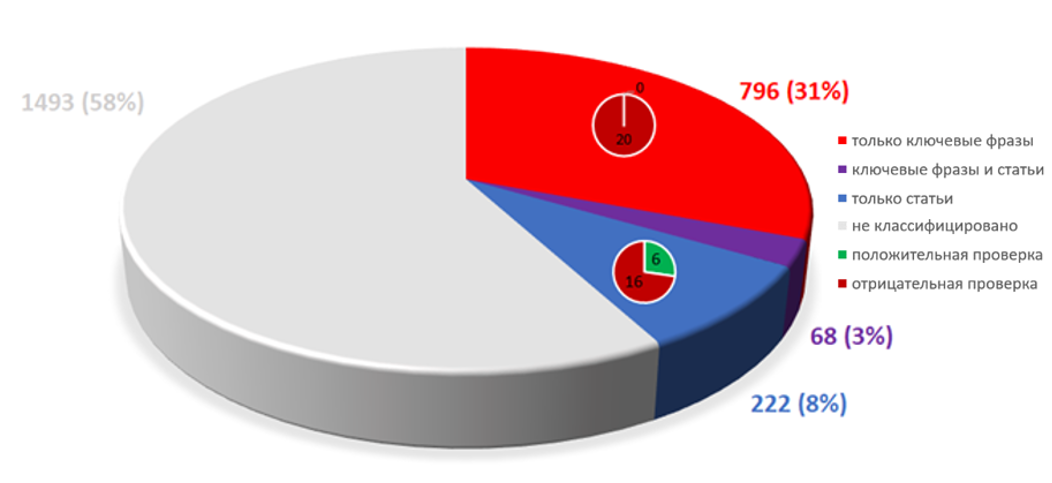
Рисунок 1 - Оценка качества методов классификации – сравнение анализа ключевых фраз (метод 1) и анализа статей (метод 3)

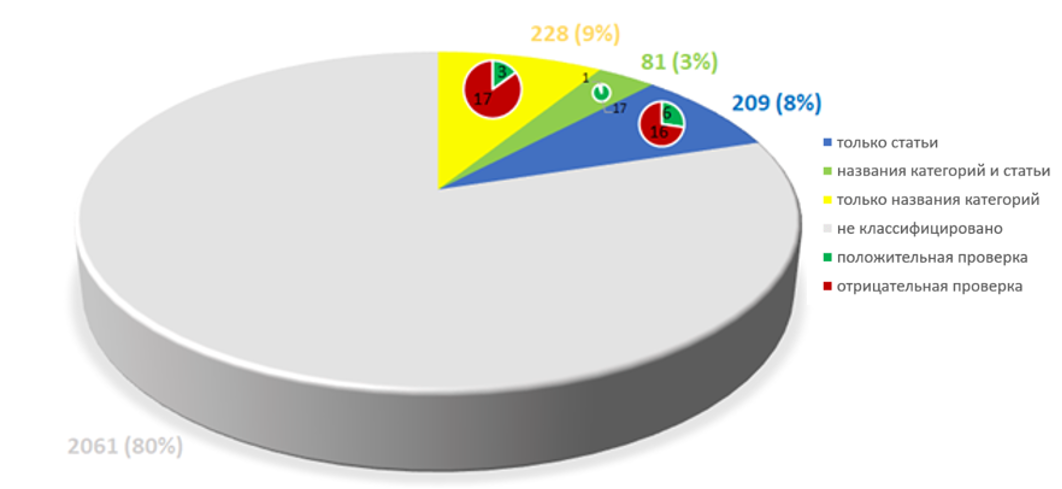
Рисунок 2 - Оценка качества методов классификации – сравнение анализа ключевых фраз (метод 1) и анализа статей (метод 3)


---
## **9. Практические рекомендации**
### **9.1. Важность разметки данных**
- Разметка данных позволяет обучать модели с учителем, что существенно повышает качество предсказаний.
- Качественная разметка улучшает точность моделей и их надежность в реальных условиях.
### **9.2. Использование нескольких методов**
- Комбинируйте различные подходы к извлечению информации для улучшения результатов анализа.
- Сравнивайте результаты разных методов и выбирайте наиболее эффективные для вашей задачи.
### **9.3. Постоянное обновление данных**
- Юридическая информация постоянно обновляется, поэтому регулярное обновление данных является необходимым условием для поддержки актуальности аналитики.


---
## **Заключение**
В ходе лекции мы рассмотрели полный процесс сбора и предобработки данных для анализа судебной практики, что является важнейшим этапом в построении аналитических систем. Мы акцентировали внимание на значении качества данных и важности последовательного подхода к их обработке.
**Основные выводы:**
- Качественный сбор и предобработка данных — основа успешного анализа.
- Использование автоматизации значительно ускоряет процесс.
- Классификация документов помогает структурировать информацию и облегчить поиск.
---
**Вопросы для закрепления материала:**
1. Почему важно автоматизировать процесс сбора данных?
2. Какие этапы включает в себя предобработка текстовых данных?
3. Как можно использовать регулярные выражения для извлечения информации из текста?
4. Какие метрики используются для оценки качества классификации?
---
**Домашнее задание:**
1. Напишите скрипт для парсинга веб-страницы и извлечения ссылок на судебные решения.
2. Реализуйте функцию очистки текста, которая выполняет все рассмотренные этапы предобработки.
3. Создайте небольшой набор данных и попробуйте классифицировать документы по категориям, используя подход анализа ключевых фраз.
---